# A data-driven assessment of Continuum of Care (CoC) effectiveness in addressing homelessness among older adults (65+) in California

Methodology Overview:
1.  **Data Integration:** Load and integrate multiple datasets, including CoC
    geospatial data, census population figures, Zillow Home Value Index (ZHVI),
    and Point-in-Time (PIT) homelessness counts.
2.  **CoC Mapping:** Programmatically map each CoC to its constituent counties 
    and/or cities to enable accurate data aggregation.
3.  **Feature Engineering:** Construct the dependent and independent variables:
    - Dependent Variable: Count of homeless individuals aged 65+ in 2023.
    - Independent Variables: CoC population (and its log), population-weighted ZHVI,
      geographical coordinates (centroids), and a spatial lag term representing
      homelessness in neighboring CoCs.
4.  **Modeling and Evaluation:**
    - Analyze the impact of different feature combinations on model performance.
    - Compare the predictive accuracy of an ANCOVA (linear model) and a
      Random Forest Regressor.
5.  **Prediction Set Analysis:** Generate predictions on a synthetic dataset where
    population is held constant to isolate the effects of other variables.
6.  **Visualization:** Generate clean, paper-ready plots for results.Methodology Overview:
1.  **Data Integration:** Load and integrate multiple datasets, including CoC
    geospatial data, census population figures, Zillow Home Value Index (ZHVI),
    and Point-in-Time (PIT) homelessness counts.
2.  **CoC Mapping:** Programmatically map each CoC to its constituent counties 
    and/or cities to enable accurate data aggregation.
3.  **Feature Engineering:** Construct the dependent and independent variables:
    - Dependent Variable: Count of homeless individuals aged 65+ in 2023.
    - Independent Variables: CoC population (and its log), population-weighted ZHVI,
      geographical coordinates (centroids), and a spatial lag term representing
      homelessness in neighboring CoCs.
4.  **Modeling and Evaluation:**
    - Analyze the impact of different feature combinations on model performance.
    - Compare the predictive accuracy of an ANCOVA (linear model) and a
      Random Forest Regressor.
5.  **Visualization:** Generate clean, paper-ready plots for results.

## 1. Setup and Imports

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from itertools import combinations

In [2]:
# Configure plot style for publications
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

## 2. Data Loading and Initial Cleaning

In [3]:
# Define file paths
DATA_DIR = "data"
COC_SHAPEFILE_DIR = os.path.join(DATA_DIR, "California")
COUNTY_ZHVI_PATH = os.path.join(DATA_DIR, "County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
CITY_ZHVI_PATH = os.path.join(DATA_DIR, "City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
CENSUS_PATH = os.path.join(DATA_DIR, "census-ca-2020-2024.csv")
PIT_COUNT_PATH = os.path.join(DATA_DIR, "cy_age.csv")

In [4]:
# Load Datasets
county_zhvi_df = pd.read_csv(COUNTY_ZHVI_PATH)
city_zhvi_df = pd.read_csv(CITY_ZHVI_PATH)
census_df = pd.read_csv(CENSUS_PATH)
pit_df = pd.read_csv(PIT_COUNT_PATH)

# Load and concatenate all CoC shapefiles
shapefile_paths = [os.path.join(COC_SHAPEFILE_DIR, f, f"{f}.shp") for f in os.listdir(COC_SHAPEFILE_DIR) if f.startswith("CA_")]
coc_gdf = pd.concat([gpd.read_file(shp) for shp in shapefile_paths], ignore_index=True)

In [5]:
def clean_name(name):
    """
    Standardize CoC names from different sources to either:
    - a comma-separated list of counties
    - a county name
    - a city name
    """
    name = name.replace(' CoC', '')
    name = name.replace(' City & County/', ', ')
    name = re.sub(r'[^/]*\/', '', name) # strip redundant city lists before a slash
    name = name.replace('City & County', '').replace('City and County', '').strip()
    name = name.replace('(Los Angeles)', '').replace('(Los Angeles County)', '').strip()
    return name.replace(' County', '').replace(' Counties', '').replace(' City', '').strip()

In [6]:
# Clean Point-in-Time (PIT) data
pit_df.rename(columns={
    'CALENDAR_YEAR': 'Year',
    'LOCATION': 'CoC_Name',
    'AGE_GROUP_PUBLIC': 'Age',
    'EXPERIENCING_HOMELESSNESS_CNT': 'Count'
}, inplace=True)
pit_df['CoC_Name'] = pit_df['CoC_Name'].apply(clean_name)
pit_df['Count'] = pd.to_numeric(pit_df['Count'], errors='coerce')

Use _geography_ for either city or county.

In [7]:
# Clean Census data
census_df.rename(columns={'County': 'Geography'}, inplace=True)
census_df['Geography'] = census_df['Geography'].apply(clean_name)

In [8]:
# Clean Zillow Home Value Index (ZHVI) data
county_zhvi_df['RegionName'] = county_zhvi_df['RegionName'].apply(clean_name)
city_zhvi_df['RegionName'] = city_zhvi_df['RegionName'].apply(clean_name)

In [9]:
# Clean and standardize CoC GeoDataFrame
coc_gdf.rename(columns={'COCNAME': 'CoC_Name'}, inplace=True)
coc_gdf['CoC_Name_Clean'] = coc_gdf['CoC_Name'].apply(clean_name)

## 3. CoC to Geography Mapping and Population Aggregation (Paper Sections 2.1, 2.2.1)

In [10]:
# Get a list of all counties in California from the census data
ca_counties = set(census_df['Geography'])

In [11]:
def get_geographies_from_coc(coc_name):
    """
    Parses a CoC name to extract constituent geographies (counties or cities).
    """
    geographies = []
    
    # Split by common delimiters for multi-geography CoCs
    potential_geos = re.split(r', | and ', clean_name(coc_name))
    
    for geo in potential_geos:
        if geo: # Ensure we don't add empty strings
            geo_type = 'County' if geo in ca_counties else 'City'
            geographies.append({'Geography': geo, 'Type': geo_type})
    return geographies

In [12]:
# Create a long-format DataFrame mapping each CoC to its constituent geographies
coc_geo_map_list = []
for _, row in coc_gdf.iterrows():
    geos = get_geographies_from_coc(row['CoC_Name'])
    for geo_info in geos:
        coc_geo_map_list.append({
            'CoC_Name': row['CoC_Name_Clean'],
            'Geography': geo_info['Geography'],
            'Type': geo_info['Type']
        })
coc_geo_map = pd.DataFrame(coc_geo_map_list).drop_duplicates().reset_index(drop=True)

In [13]:
# Aggregate Population Data to CoC Level
# Note: City populations are not in census_df, so we only join on counties.
coc_pop = pd.merge(coc_geo_map[coc_geo_map['Type'] == 'County'], census_df, on='Geography', how='left')
coc_population_df = coc_pop.groupby('CoC_Name')[['2023']].sum().reset_index()
coc_population_df.rename(columns={'2023': 'Population'}, inplace=True)

In [14]:
# Create a population mapping for weighted averages
county_pop_map = coc_pop.set_index('Geography')['2023']

In [15]:
# Source: ACS 1/5-Year Estimates Detailed Tables
city_pop_map = pd.Series({
    "Glendale": 192270,
    "Long Beach": 458491,
    "Pasadena": 266090,
})

In [16]:
pop_map = pd.concat((county_pop_map, city_pop_map))

# Subtract LA's city-level CoCs population from LA's county-wide CoC
pop_map.loc[pop_map.index == 'Los Angeles'] -= pop_map[pop_map.index == "Glendale"].to_numpy() \
    + pop_map[pop_map.index == "Long Beach"].to_numpy() + pop_map[pop_map.index == "Pasadena"].to_numpy()

In [17]:
coc_population_df.loc[coc_population_df.CoC_Name == 'Los Angeles', 'Population'] = pop_map[pop_map.index == "Los Angeles"].to_numpy()[0]
coc_population_df.loc[len(coc_population_df)] = ["Glendale", pop_map[pop_map.index == "Glendale"].to_numpy()[0]]
coc_population_df.loc[len(coc_population_df)] = ["Long Beach", pop_map[pop_map.index == "Long Beach"].to_numpy()[0]]
coc_population_df.loc[len(coc_population_df)] = ["Pasadena", pop_map[pop_map.index == "Pasadena"].to_numpy()[0]]

## 4. Feature Engineering (Paper Section 2.2)

### 4.1 Dependent Variable: Homelessness Count (65+) in 2023

In [18]:
homeless_65_2023 = pit_df[(pit_df['Age'] == '65+') & (pit_df['Year'] == 2023) & (pit_df['CoC_Name'] != 'California')]
homeless_65_2023 = homeless_65_2023[['CoC_Name', 'Count']].rename(columns={'Count': 'Homeless_65_2023'})

### 4.2 Independent Variables

In [19]:
# --- Housing Price Data (ZHVI - Section 2.2.2) ---
def get_mean_zhvi_for_year(zhvi_df, year):
    """Extracts and calculates the mean ZHVI for a given year."""
    year_cols = [c for c in zhvi_df.columns if c.startswith(str(year))]
    if not year_cols:
        return pd.DataFrame(columns=['Geography', 'ZHVI'])
    
    zhvi_year = zhvi_df[['RegionName'] + year_cols]
    zhvi_year_melted = zhvi_year.melt(id_vars='RegionName', value_vars=year_cols, value_name='ZHVI')
    mean_zhvi = zhvi_year_melted.groupby('RegionName')['ZHVI'].mean().reset_index()
    return mean_zhvi.rename(columns={'RegionName': 'Geography'})

In [20]:
county_zhvi_df = county_zhvi_df[county_zhvi_df.State=="CA"]
city_zhvi_df = city_zhvi_df[city_zhvi_df.State=="CA"]
city_zhvi_df = city_zhvi_df[(city_zhvi_df.RegionName=="Glendale")|(city_zhvi_df.RegionName=="Long Beach")|(city_zhvi_df.RegionName=="Pasadena")]

In [21]:
zhvi_2023_county = get_mean_zhvi_for_year(county_zhvi_df, 2023)
zhvi_2023_city = get_mean_zhvi_for_year(city_zhvi_df, 2023)
zhvi_2023 = pd.concat([zhvi_2023_county, zhvi_2023_city]).dropna()

In [22]:
def calculate_weighted_metric(coc_map, metric_df, population_map):
    """Calculates a population-weighted average metric for each CoC."""
    merged = pd.merge(coc_map, metric_df, on='Geography', how='left')
    merged['Population'] = merged['Geography'].map(population_map).fillna(1)
    merged['Weighted_Metric'] = merged['ZHVI'] * merged['Population']
    
    agg = merged.groupby('CoC_Name').agg(
        Weighted_Metric_Sum=('Weighted_Metric', 'sum'),
        Population_Sum=('Population', 'sum')
    )
    agg['Final_Metric'] = agg['Weighted_Metric_Sum'] / agg['Population_Sum']
    return agg[['Final_Metric']].rename(columns={'Final_Metric': 'Home prices'})

In [23]:
coc_zhvi_df = calculate_weighted_metric(coc_geo_map, zhvi_2023, pop_map)

In [24]:
# --- Geographical Features (Section 2.2.3) ---
# Adjacency Graph
coc_gdf_proj = coc_gdf.to_crs(epsg=3310) # Project for accurate touches
adjacency = {row.CoC_Name_Clean: [] for _, row in coc_gdf_proj.iterrows()}
for index, coc in coc_gdf_proj.iterrows():
    neighbors = coc_gdf_proj[coc_gdf_proj.geometry.touches(coc.geometry)].CoC_Name_Clean.tolist()
    adjacency[coc.CoC_Name_Clean].extend(neighbors)

In [25]:
# Centroids (Latitude and Longitude) - calculated on projected CRS, then converted to WGS84
centroids_proj = coc_gdf_proj.geometry.centroid
centroids_wgs84 = centroids_proj.to_crs(epsg=4326)
coc_gdf['Longitude'] = centroids_wgs84.x
coc_gdf['Latitude'] = centroids_wgs84.y

In [26]:
# Spatial Lag
spatial_lag_values = {}
homeless_map = homeless_65_2023.set_index('CoC_Name')['Homeless_65_2023']
for coc, neighbors in adjacency.items():
    if not neighbors:
        spatial_lag_values[coc] = 0
        continue
    neighbor_homelessness = homeless_map.reindex(neighbors).dropna()
    spatial_lag_values[coc] = neighbor_homelessness.mean() if not neighbor_homelessness.empty else 0

In [27]:
spatial_lag_df = pd.DataFrame(list(spatial_lag_values.items()), columns=['CoC_Name', 'Spatial lag'])

In [28]:
# ## 5. Final DataFrame Assembly
final_df = pd.merge(homeless_65_2023, coc_population_df, on='CoC_Name', how='inner')
final_df = pd.merge(final_df, coc_zhvi_df, on='CoC_Name', how='inner')
final_df = pd.merge(final_df, coc_gdf[['CoC_Name_Clean', 'Latitude', 'Longitude']].rename(columns={'CoC_Name_Clean': 'CoC_Name'}), on='CoC_Name', how='inner')
final_df = pd.merge(final_df, spatial_lag_df, on='CoC_Name', how='inner')

In [29]:
# Add log of population
final_df['log(Population)'] = np.log(final_df['Population'])

In [30]:
# Clean up and set index
final_df.dropna(inplace=True)
final_df.set_index('CoC_Name', inplace=True)

Final clean DataFrame for modeling

In [31]:
final_df

,Homeless_65_2023,Population,Home prices,Latitude,Longitude,Spatial lag,log(Population)
CoC_Name,,,,,,,
Santa Clara,911.0,1897137,1.515416e+06,37.231452,-121.694269,374.166667,14.455856
San Francisco,922.0,819151,1.300793e+06,37.755733,-122.442878,511.666667,13.616024
Alameda,953.0,1638142,1.081076e+06,37.646538,-121.885974,664.800000,14.309073
Sacramento,785.0,1594506,5.288779e+05,38.449053,-121.344514,230.500000,14.282075
Sonoma,311.0,483366,8.030657e+05,38.528345,-122.886506,105.600000,13.088529
Contra Costa,796.0,1162179,8.122307e+05,37.919137,-121.926565,562.000000,13.965807
"Monterey, San Benito",216.0,503978,8.128832e+05,36.331786,-121.188982,387.333333,13.130288
Marin,191.0,255706,1.458793e+06,38.072329,-122.718031,616.500000,12.451784
Santa Cruz,205.0,263699,1.145536e+06,37.056255,-122.001516,506.000000,12.482564


## 6. Modeling and Evaluation (Paper Section 2.3)

In [32]:
# Define features and target
TARGET = 'Homeless_65_2023'
FEATURES = ['Population', 'log(Population)', 'Home prices', 'Latitude', 'Longitude', 'Spatial lag']
X = final_df[FEATURES]
y = final_df[TARGET]

### 6.1 Feature Combination Analysis

In [33]:
rmse_results = {}
for i in range(1, len(FEATURES) + 1):
    for combo in combinations(FEATURES, i):
        if 'Population' in combo and 'log(Population)' in combo:
            continue
        combo_list = list(combo)
        X_combo = X[combo_list]
        
        # X_train, X_test, y_train, y_test = train_test_split(X_combo, y, test_size=0.3, random_state=42)
        X_train, X_test, y_train, y_test = X_combo, X_combo, y, y
        
        model = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        rmse_results[combo] = rmse

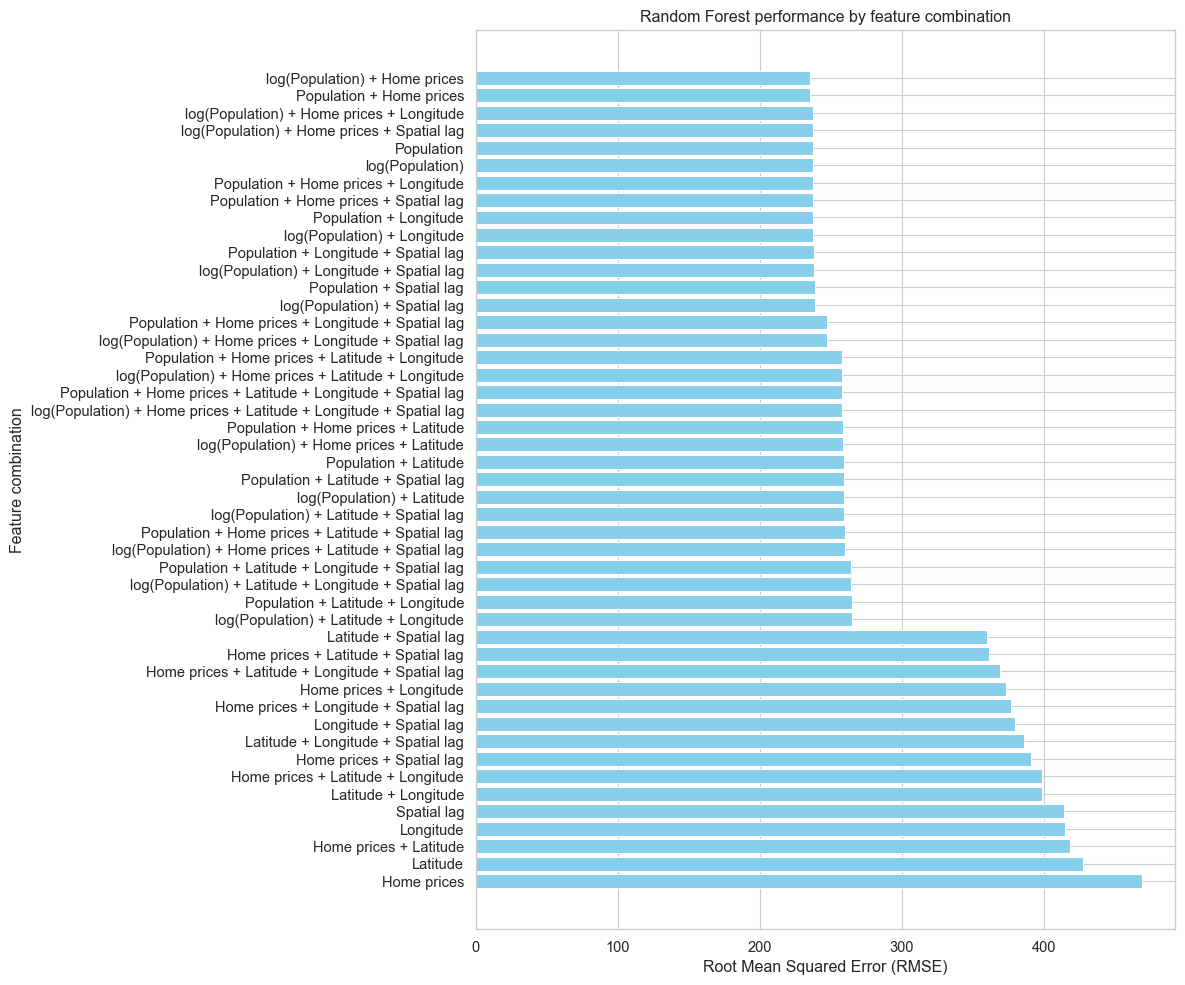

In [34]:
# Plotting RMSE results
plt.figure(figsize=(12, 10))
sorted_results = sorted(rmse_results.items(), key=lambda item: item[1], reverse=True)
combo_labels = [' + '.join(c) for c, _ in sorted_results]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color='skyblue')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Feature combination')
plt.title('Random Forest performance by feature combination')
plt.tight_layout()
plt.show()

In [35]:
import statsmodels.formula.api as smf

rmse_results = {}
for i in range(1, len(FEATURES) + 1):
    for combo in combinations(FEATURES, i):
        if 'Population' in combo and 'log(Population)' in combo:
            continue
        combo_list = list(combo)
        X_combo = X[combo_list]
        
        # X_train, X_test, y_train, y_test = train_test_split(X_combo, y, test_size=0.3, random_state=42)
        X_train, X_test, y_train, y_test = X_combo, X_combo, y, y
        
        # model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
        formula = f'Homeless_65_2023 ~ {' + '.join([f'Q("{feature}")' for feature in combo])}'
        model = smf.ols(formula, data=final_df).fit()

        # preds = model.predict(sm.add_constant(X_test))
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        rmse_results[combo] = rmse

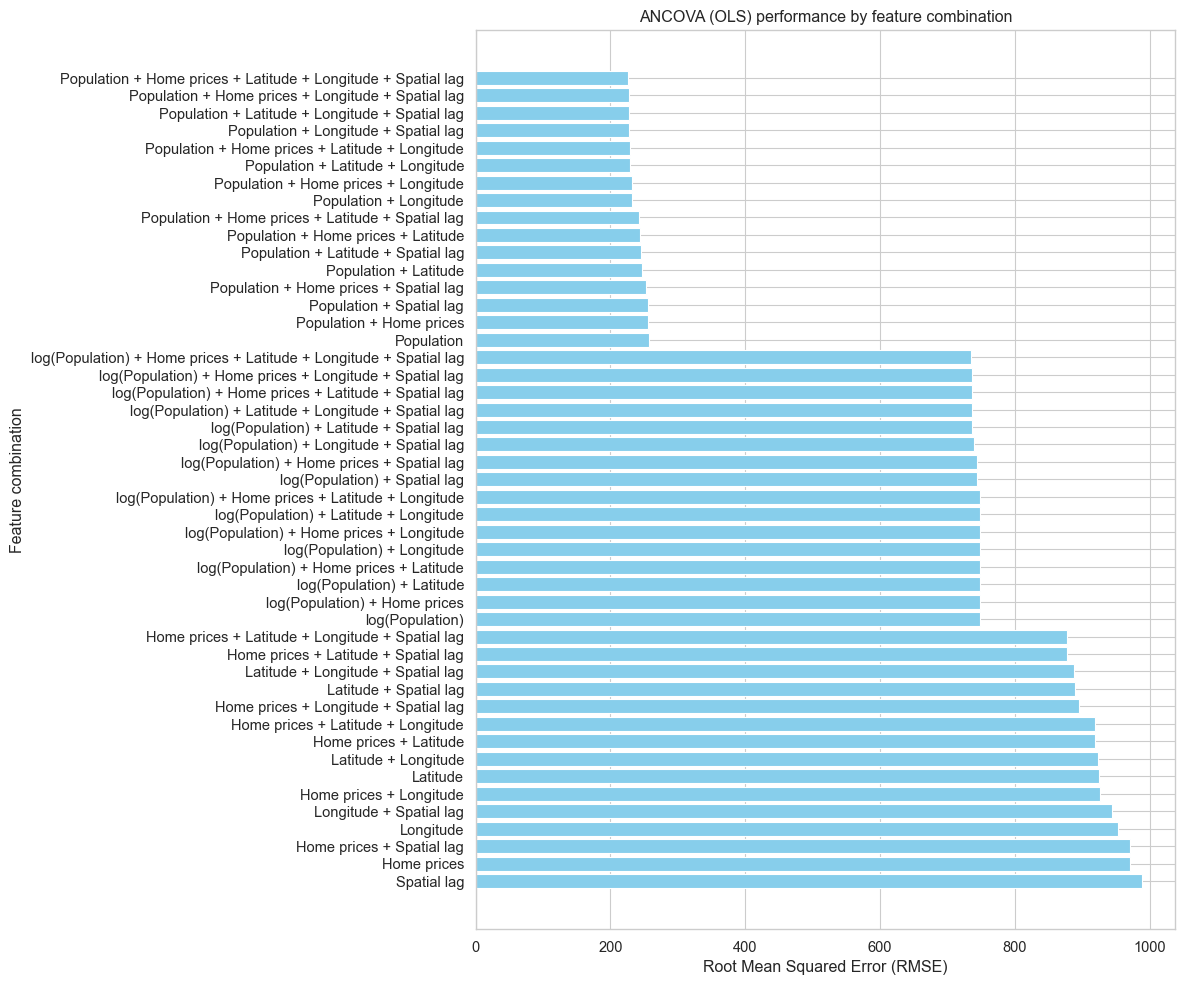

In [36]:
# Plotting RMSE results
plt.figure(figsize=(12, 10))
sorted_results = sorted(rmse_results.items(), key=lambda item: item[1], reverse=True)
combo_labels = [' + '.join(c) for c, _ in sorted_results]
rmse_values = [r for _, r in sorted_results]
plt.barh(combo_labels, rmse_values, color='skyblue')
plt.xlabel('Root Mean Squared Error (RMSE)')
plt.ylabel('Feature combination')
plt.title('ANCOVA (OLS) performance by feature combination')
plt.tight_layout()
plt.show()

### 6.2 Model Comparison: ANCOVA vs. Random Forest

In [37]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = X, X, y, y

In [38]:
# ANCOVA (OLS Linear Model)
ols_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
ols_preds = ols_model.predict(sm.add_constant(X_test))
ols_rmse = np.sqrt(mean_squared_error(y_test, ols_preds))
print(f"\nANCOVA (OLS) Model RMSE: {ols_rmse:.2f}")
print(ols_model.summary())


ANCOVA (OLS) Model RMSE: 184.55
                            OLS Regression Results                            
Dep. Variable:       Homeless_65_2023   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     171.3
Date:                Thu, 14 Aug 2025   Prob (F-statistic):           1.90e-25
Time:                        23:05:40   Log-Likelihood:                -292.02
No. Observations:                  44   AIC:                             598.0
Df Residuals:                      37   BIC:                             610.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const    

In [39]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print(f"Random Forest Model RMSE: {rf_rmse:.2f}")

Random Forest Model RMSE: 257.17


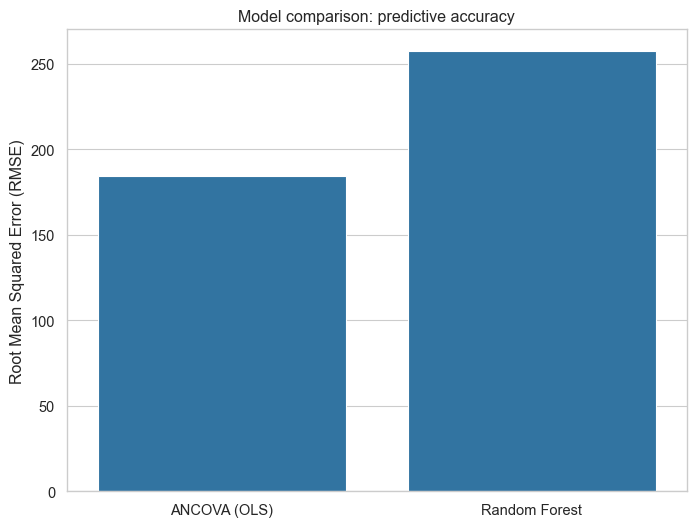

In [40]:
# Comparison Plot
plt.figure(figsize=(8, 6))
model_names = ['ANCOVA (OLS)', 'Random Forest']
rmse_scores = [ols_rmse, rf_rmse]
sns.barplot(x=model_names, y=rmse_scores)
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Model comparison: predictive accuracy')
plt.show()

## 7. Final Model Analysis and Visualization

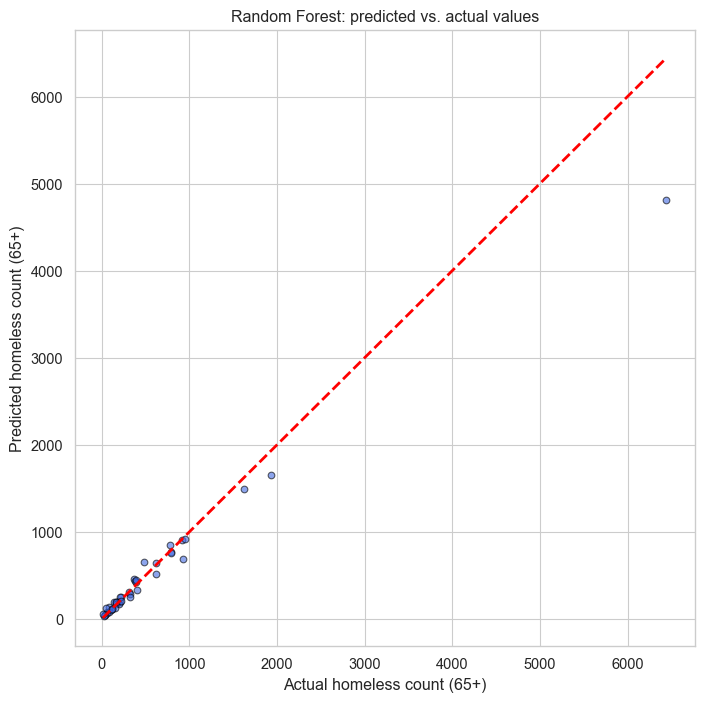

In [41]:
# --- Predicted vs. Actual Plot ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds, alpha=0.6, edgecolors='k', c='royalblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red', lw=2)
plt.xlabel('Actual homeless count (65+)')
plt.ylabel('Predicted homeless count (65+)')
plt.title('Random Forest: predicted vs. actual values')
plt.grid(True)
plt.show()

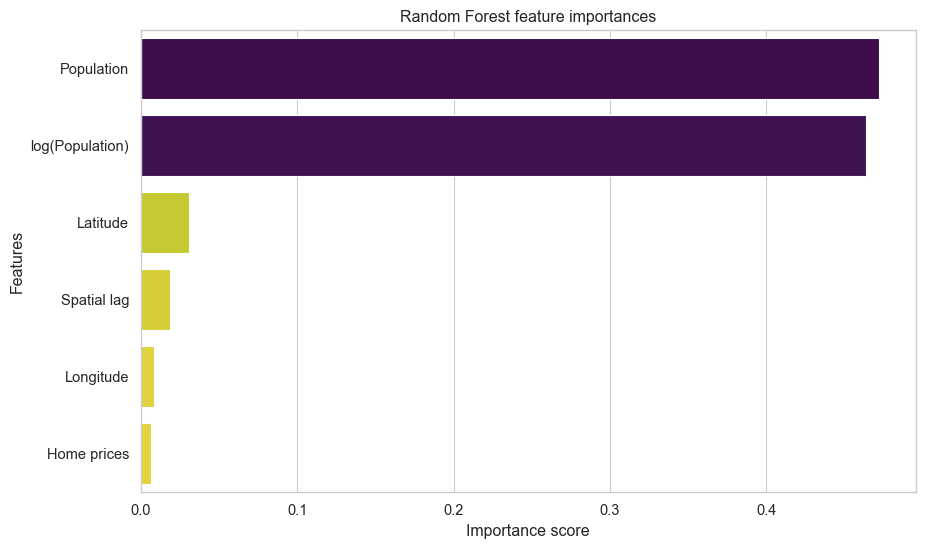

In [42]:
# --- Feature Importance Plot ---
feature_importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, hue=feature_importances, legend=False, palette='viridis_r')
plt.xlabel('Importance score')
plt.ylabel('Features')
plt.title('Random Forest feature importances')
plt.show()

## 8. Prediction Set with Averaged Population


--- Generating predictions for a constant average population ---
Using an average population of 890,879 for all CoCs.


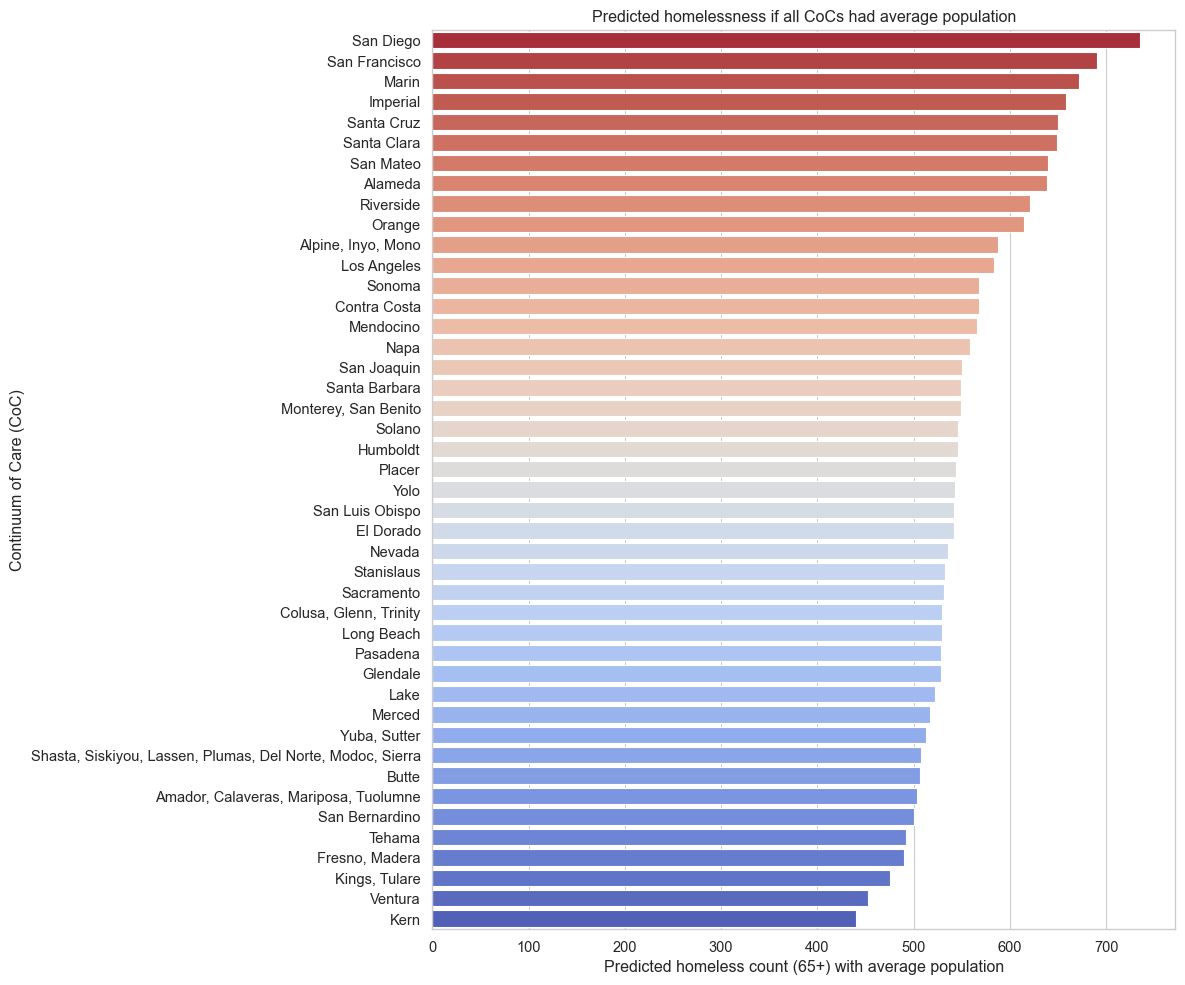

In [43]:
# This section creates a synthetic dataset where the population of every CoC is
# set to the statewide average. This allows us to predict homelessness counts
# based on factors other than population size (e.g., housing costs, location).

print("\n--- Generating predictions for a constant average population ---")

# Create a copy of the final dataframe for our prediction set
prediction_set_df = final_df.copy()

# Calculate the average population and its log
avg_population = prediction_set_df['Population'].mean()
log_avg_population = np.log(avg_population + 1)
print(f"Using an average population of {avg_population:,.0f} for all CoCs.")

# Replace the population features with the average values
prediction_set_df['Population'] = avg_population
prediction_set_df['log(Population)'] = log_avg_population

# Select the same features the model was trained on
X_prediction = prediction_set_df[FEATURES]

# Use the trained Random Forest model to predict on this new dataset
prediction_set_preds = rf_model.predict(X_prediction)

# Add predictions to the dataframe
prediction_set_df['Predicted_Homeless_Avg_Pop'] = prediction_set_preds

# --- Visualize the Prediction Set Results ---
# Sort for better visualization
sorted_predictions = prediction_set_df.sort_values('Predicted_Homeless_Avg_Pop', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Predicted_Homeless_Avg_Pop', y=sorted_predictions.index, data=sorted_predictions, palette='coolwarm_r', hue=sorted_predictions.index, dodge=False, legend=False)
plt.xlabel('Predicted homeless count (65+) with average population')
plt.ylabel('Continuum of Care (CoC)')
plt.title('Predicted homelessness if all CoCs had average population')
plt.tight_layout()
plt.show()

In [44]:
def plot_metric_on_map(
    metric_df, coc_geodata, column_name, title, cmap="viridis", label=None
):
    """
    Generates a choropleth map of a specified metric for California CoCs.

    Args:
        metric_df (pd.DataFrame): DataFrame containing the metric data with CoC names as index.
        coc_geodata (gpd.GeoDataFrame): GeoDataFrame with CoC geometries and a 'CoC_Name_Clean' column.
        column_name (str): The name of the column in metric_df to plot.
        title (str): The title for the map.
        cmap (str, optional): The colormap to use. Defaults to 'viridis'.
        label (str, optional): The label for the color bar. If None, uses column_name.
    """
    if label is None:
        label = column_name

    # Merge the metric data with the geospatial data
    map_data = coc_geodata.merge(
        metric_df[[column_name]],
        left_on="CoC_Name_Clean",
        right_index=True,
        how="inner",
    )

    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    map_data.plot(
        column=column_name,
        ax=ax,
        legend=True,
        cmap=cmap,
        legend_kwds={
            "label": label,
            "shrink": 0.8,
            # "orientation": "horizontal",
        },
    )

    ax.set_title(title, fontdict={"fontsize": "16", "fontweight": "3"})
    ax.set_axis_off()
    plt.show()

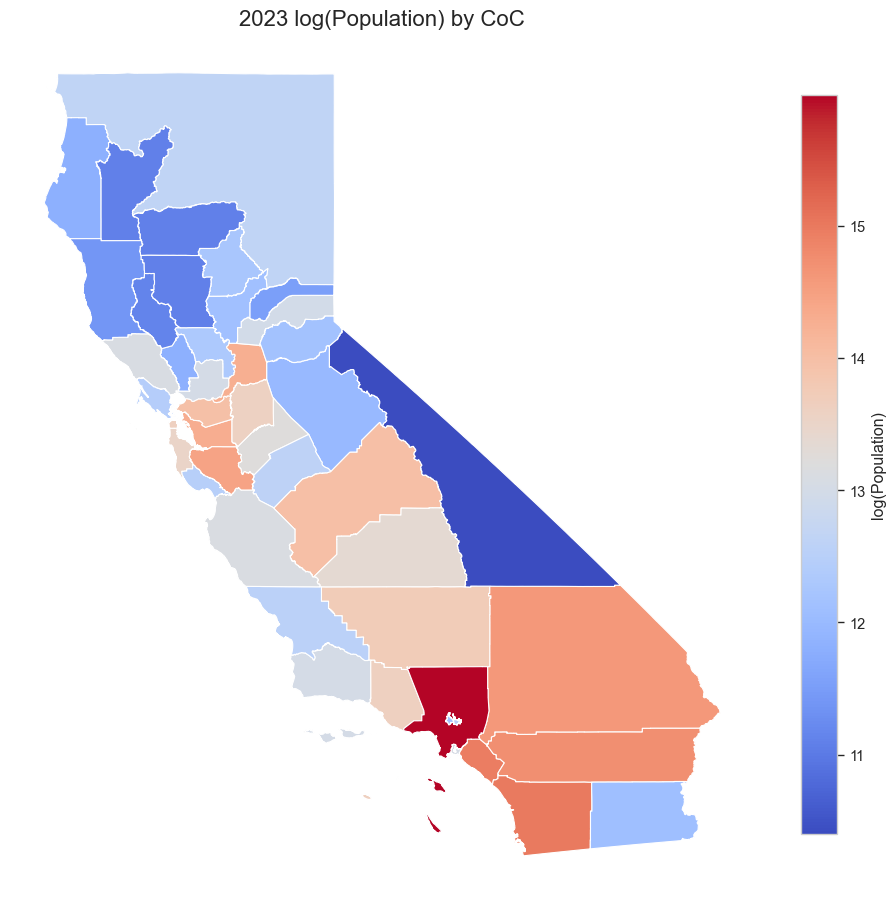

In [45]:
plot_metric_on_map(
    final_df,
    coc_gdf,
    column_name="log(Population)",
    title="2023 log(Population) by CoC",
    cmap="coolwarm",
)

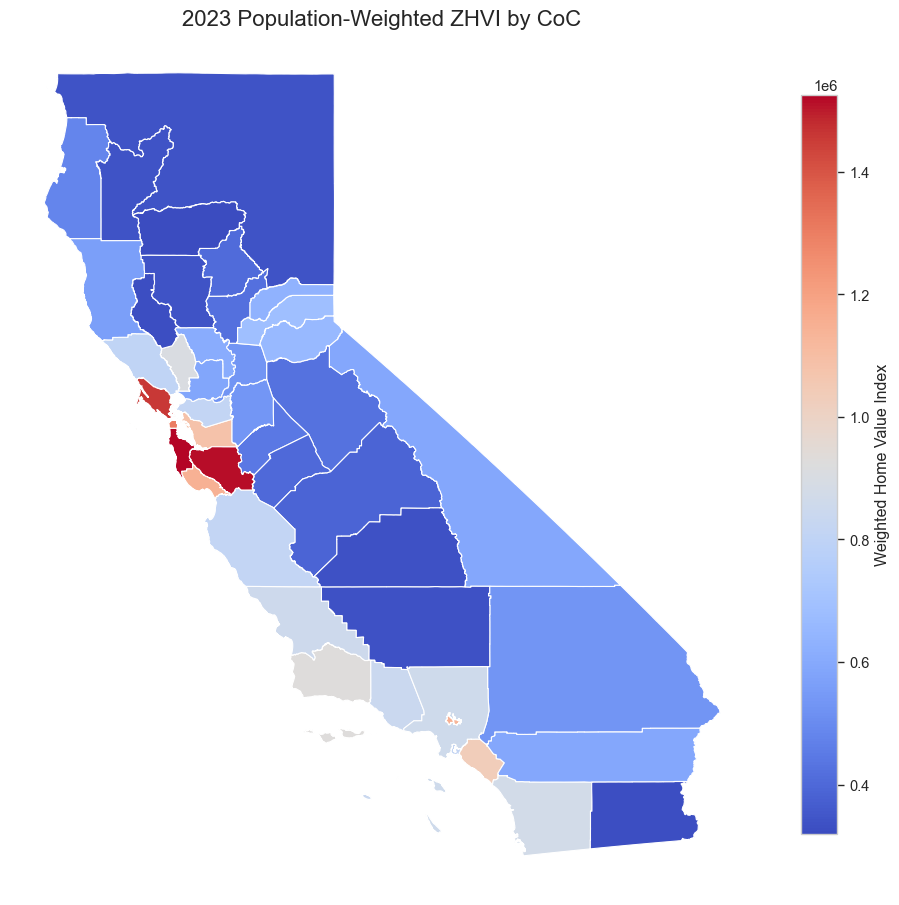

In [46]:
plot_metric_on_map(
    final_df,
    coc_gdf,
    column_name="Home prices",
    title="2023 Population-Weighted ZHVI by CoC",
    cmap="coolwarm",
    label="Weighted Home Value Index",
)

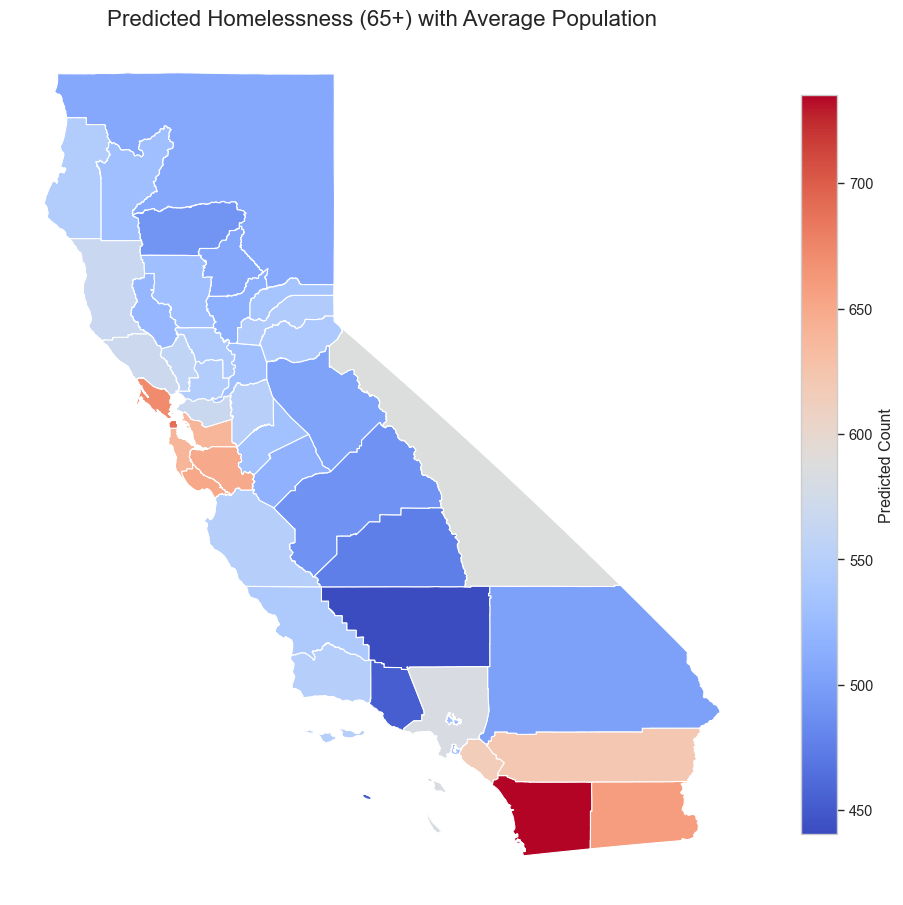

In [47]:
plot_metric_on_map(
    prediction_set_df,
    coc_gdf,
    column_name="Predicted_Homeless_Avg_Pop",
    title="Predicted Homelessness (65+) with Average Population",
    cmap="coolwarm",
    label="Predicted Count",
)